# 3. Percolation

A simple lattice model displaying a geometrical phase transition  is percolation, where the sites (or the bonds) of a $d$-dimensional lattice are  randomly occupied with a probability $p$. 
As the name suggests, the model is inspired by the percolation of a fluid through a random porous medium. Pores can allow locally the passage of the fluid, and the question is whether the fluid entering from one end of the medium is able to percolate to the other side. The answer to this question boils down to the presence of a path connecting the two ends. Percolation is relevant for a wide variety of problems involving transport in random media, including fluid flow in rocks and soil, coffee  extraction, and conduction in disordered solids.

Here we will consider both bond and site percolation depending on which element can be occupied with probability $p$. In both cases, there is a critical value $p_c$ above which there is a path connecting the two ends of the lattice. For $p <p_c$, occupied regions form a set of disconnected clusters whose average size increases with $p$ and in the limit of an infinite system diverges when $p \to p_c$.

Bond percolation (square lattice):
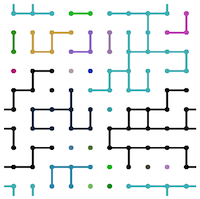

Site percolation (on hexagonal lattice):
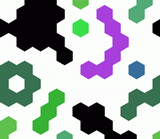

In this nootebook we will explore site and bond percolation, learn about fractal analysis and apply percolataion ideas to a practical case: the patterns of urbanization in Europe.

In [1]:
import pylab 
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import scipy
%matplotlib inline

# 3.A Site percolation on the square lattice

Here we will use simple functions to study percolation on the square lattice. 

### Exercise 3.1 Generate configuration
Write a function to generate a configuration of a square lattice as a function of p.

In [2]:
def generate_conf(p,L):
    """
    Create a configuration for the percolation 
    model on a square lattice with size L
    
    
    Parameters
    ----------
    L : int
        The system size.

    p: the occupation probability

    Returns
    -------
    M : np.array, (L, L)
    """
    M = np.random.choice([0,1], (L, L), p=[1-p, p])
    return M

Use the function imshow() to display the configuration.

[[0 1 1 1 1]
 [1 1 0 0 1]
 [0 0 1 0 1]
 [1 1 1 0 1]
 [0 0 0 0 1]]


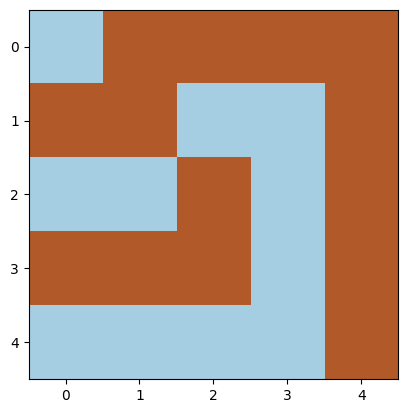

In [3]:
M = generate_conf(0.5, 5)
print(M)
plt.imshow(M, cmap="Paired")

### Exercise 3.2: Clusters in site percolation
Find  the clusters associated to the configurations M and and display them for different values of $p$. You can adapt the function used in notebook 2 or use the function 

scipy.ndimage.measurements.label()
https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.ndimage.measurements.label.html

As a result you should get a new LxL np.array M_colored in which each element is an integer color=1,....n_color, where n_color is the number of different clusters. 

Use imshow() to plot clusters for 6 different values of $0<p<1$.

In [4]:
import matplotlib.colors as mcolors

background_color = [0.1, 0.1, 0.1, 1]  # dark grey for empty sites
cluster_colors = plt.cm.tab20(np.linspace(0, 1, max(20, 1)))

all_colors = np.vstack([background_color, cluster_colors])
cmap = mcolors.ListedColormap(all_colors)

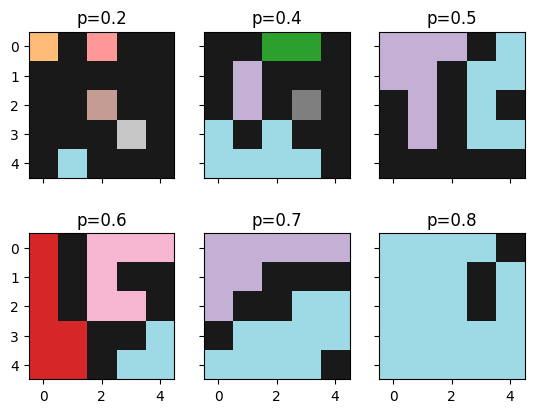

In [5]:
M_colored_02 = scipy.ndimage.label(generate_conf(0.2, 5))[0]
M_colored_04 = scipy.ndimage.label(generate_conf(0.4, 5))[0]
M_colored_05 = scipy.ndimage.label(generate_conf(0.5, 5))[0]
M_colored_06 = scipy.ndimage.label(generate_conf(0.6, 5))[0]
M_colored_07 = scipy.ndimage.label(generate_conf(0.7, 5))[0]
M_colored_08 = scipy.ndimage.label(generate_conf(0.8, 5))[0]

fig, axs = plt.subplots(2, 3)
axs[0, 0].imshow(M_colored_02, cmap=cmap)
axs[0, 0].set_title('p=0.2')
axs[0, 1].imshow(M_colored_04, cmap=cmap)
axs[0, 1].set_title('p=0.4')
axs[0, 2].imshow(M_colored_05, cmap=cmap)
axs[0, 2].set_title('p=0.5')
axs[1, 0].imshow(M_colored_06, cmap=cmap)
axs[1, 0].set_title('p=0.6')
axs[1, 1].imshow(M_colored_07, cmap=cmap)
axs[1, 1].set_title('p=0.7')
axs[1, 2].imshow(M_colored_08, cmap=cmap)
axs[1, 2].set_title('p=0.8')

for ax in axs.flat:
    ax.label_outer()


### Exercise 3.3: Cluster distribution

It is known that for the square lattice site percolation, the critical occupation probability is $p_c= 0.59274$ (the exact value is not known). There are, however, exact results known for many properties of percolation. In particular, it is known that at $p=p_c$ the clusters are distributed as a power law
$n(s) \sim s^{-\tau}$ with $\tau=187/91$. Verify this law by calculating the cluster size distribution $n(s)$,
for site percolation on the square lattice for a large
system size (for instance 400x400)

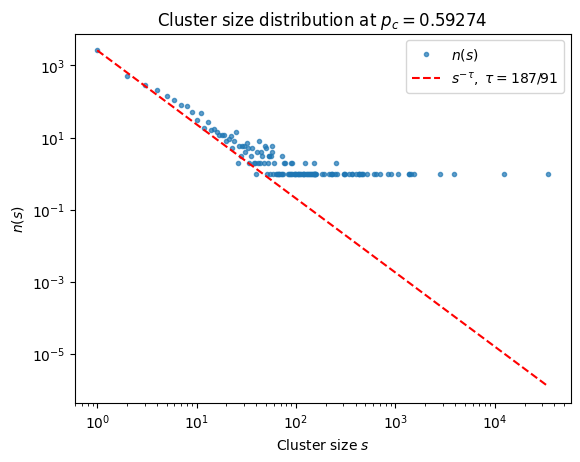

In [6]:
from collections import Counter

p_c = 0.59274
L = 400
M = generate_conf(p_c, L)

def get_cluster_sizes(labeled_grid):
    labels = labeled_grid[labeled_grid > 0]
    sizes = Counter(labels.flatten())
    return np.array(list(sizes.values()))

labeled, n = scipy.ndimage.label(M)
sizes = get_cluster_sizes(labeled)

unique_sizes, size_counts = np.unique(sizes, return_counts=True)

# Log-log plot
fig, ax = plt.subplots()
ax.loglog(unique_sizes, size_counts, '.', label='$n(s)$', alpha=0.7)

# Power law reference line
tau = 187/91
s_range = np.logspace(0, np.log10(unique_sizes.max()), 200)
C = size_counts[0] 
y_theory = C * (s_range**(-tau))
ax.loglog(s_range, y_theory, 'r--', label=r'$s^{-\tau},\ \tau=187/91$')

ax.set_xlabel('Cluster size $s$')
ax.set_ylabel('$n(s)$')
ax.set_title(f'Cluster size distribution at $p_c = {p_c}$')
ax.legend()
plt.show()

### Exercise 3.4: Scaling of the order parameter
Consider now $p>p_c$ and calculate the fraction of nodes $P(p)$ in the largest cluster at a series of points $p = p_c+2^{-n}$ 
for a large enough lattice and a range of
$n$ (for example between $n=2$ and $n=10$). Do a log-log plot of 
$P(p)$ versus $(p-p_c)$. Theory says that 
$P(p) \sim (p-p_c)^\beta$
with $\beta=5/36$. You will see that the match is not perfect.

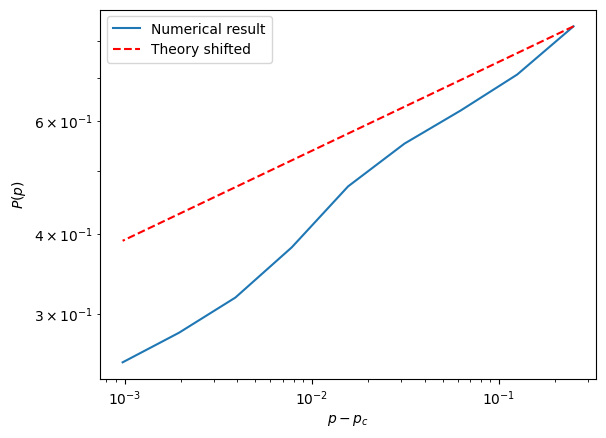

In [7]:
L = 400
p_c = 0.59274
beta = 5/36

cluster_frac = []
probabilities = []

for n in range(2, 11):
    p = p_c + 2**(-n)
    iters = []
    for _ in range(100):
        M_labeled, num = scipy.ndimage.label(generate_conf(p, L))
        biggest_cluster_size = get_cluster_sizes(M_labeled).max()
        iters.append(biggest_cluster_size / L**2)
    mean_cluster_frac = np.mean(iters)
    cluster_frac.append(mean_cluster_frac)
    probabilities.append(p)

cluster_frac = np.array(cluster_frac)
probabilities = np.array(probabilities)
p_diff = probabilities - p_c

fig, ax = plt.subplots()
ax.loglog(p_diff, cluster_frac,  label='Numerical result')
shift = cluster_frac[0] / (p_diff[0]**beta)
ax.loglog(p_diff, shift * (p_diff**beta), 'r--', label='Theory shifted')

ax.set_xlabel('$p - p_c$')
ax.set_ylabel('$P(p)$')
ax.legend()
plt.show()

### Exercise 3.5 - Finite size scaling
We can extract better values for rom small simulations by explicitly including the length L into our analysis.
Let $P(p| L)$ be the mean fraction of nodes in the
largest cluster for a system of size L.
On a single graph, plot $P(p;L)$ versus p for site
percolation L = 5, 10, 20, 50, and 100, focusing on
the region around $p = p_c$ where they differ from
one another. (At L = 10 you will want p to range
from 0:25 to 0:75; for L = 50 the range should be
from 0:45 to 0:55 or so.) Five or ten points will be
enough. You will discover that the sample-to-sample
variations are large (another  finite-size effct), so
average each curve over perhaps ten or twenty 
realizations.

Test the following scaling function:
$$ P(p,L)= L^{-\beta/\nu} f((p-p_c)L^{1/\nu}$$
where $\nu=4/3$.  

To test you should employ a data collapse by defining $X=(p-p_c)L^{1/\nu}$ and $Y=P(p,L)L^{\beta/\nu}$ and then plotting $Y$ versus $X$ for all the values of $L$ in the same graph.

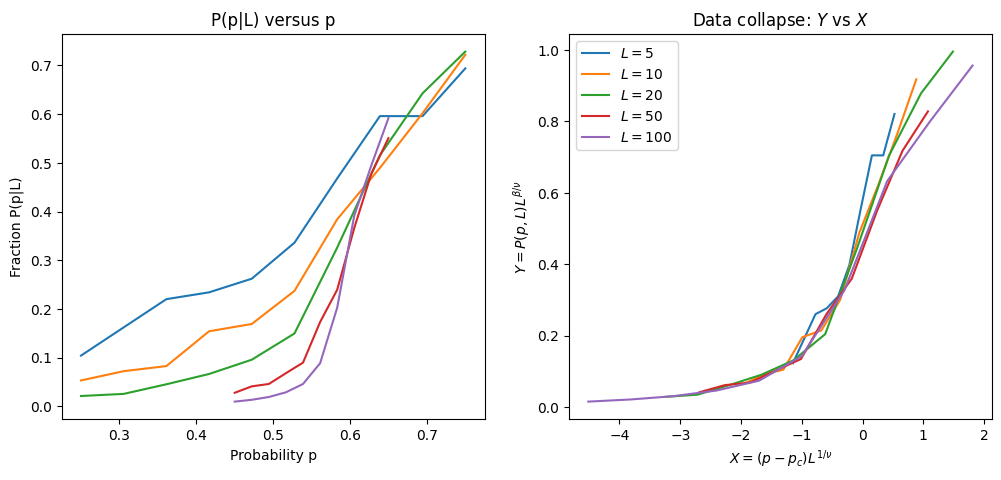

In [8]:
p_c = 0.59274
beta = 5/36
nu = 4/3
Ls = [5, 10, 20, 50, 100]
probs_small = np.linspace(0.25, 0.75, 10)
probs_large = np.linspace(0.45, 0.65, 10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
for L in Ls:
    probs = probs_small if L in [5, 10, 20] else  probs_large
    X = []
    Y = []
    probs_pL = []
    for p in probs:
        iters = []
        for _ in range(20):
            M_labeled, num = scipy.ndimage.label(generate_conf(p, L))
            biggest_cluster_size = get_cluster_sizes(M_labeled).max()
            iters.append(biggest_cluster_size / L**2)
        prob_pL = np.mean(iters)
        probs_pL.append(prob_pL)

        X.append((p - p_c) * L**(1/nu))
        Y.append(prob_pL * L**(beta/nu))

    ax1.plot(probs, probs_pL, label=f'$L={L}$')
    ax2.plot(X, Y, label=f'$L={L}$')


ax1.set_title("P(p|L) versus p")
ax1.set_xlabel("Probability p")
ax1.set_ylabel("Fraction P(p|L)")
ax2.set_title("Data collapse: $Y$ vs $X$")
ax2.set_xlabel(r"$X = (p-p_c) L^{1/\nu}$")
ax2.set_ylabel(r"$Y = P(p,L) L^{\beta/\nu}$")
ax2.legend()
plt.legend()
plt.show()

### Exercise 3.6 - The percolating cluster
Set $p=p_c$ and generate a large configuration of the site percolation problem (at least L=400). Select the largest cluster and compute its fractal dimension using the box counting method.

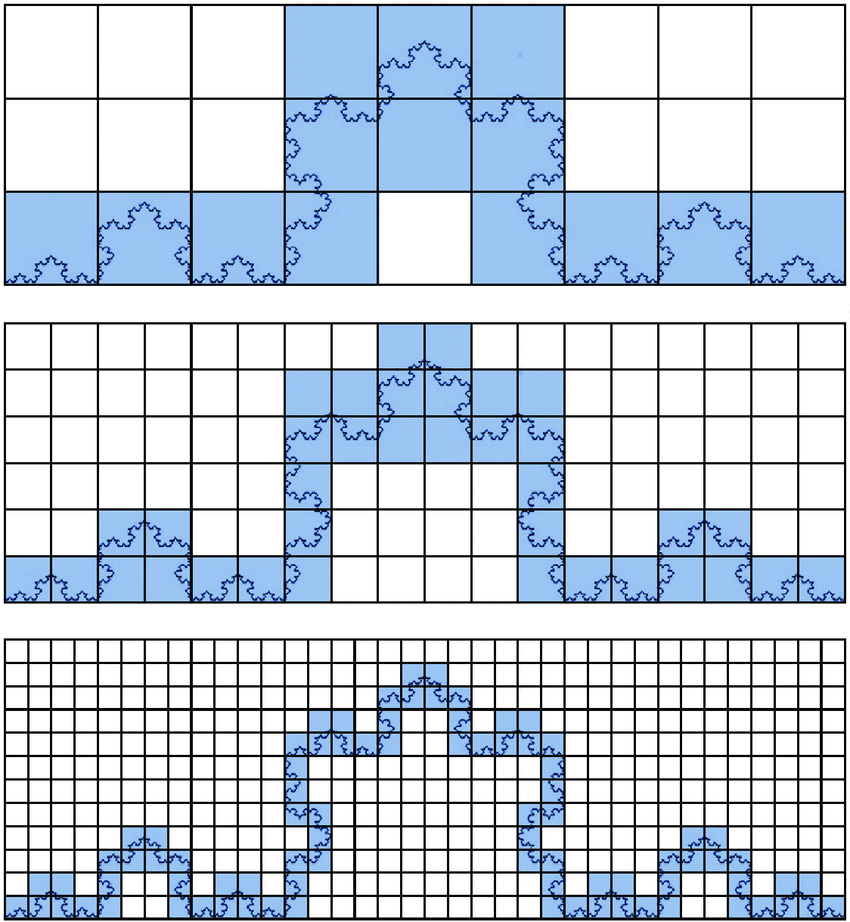

The method is based on a grid made of cells of changing cell sizes $b$. Superimpose a grid of cell size $b$  with the percolation cluster and count how many cells $N(b)$ contain sites belonging to the cluster. By plotting $N(b)$ versus $b$ you should obtain $N(b) \propto b^{-D}$ where $D$ is the fractal dimension of the percolating cluster.

Follow these steps:
- create an array m_cl where m_cl[i,j]=1 if the site belongs to the largest cluster.
- write a function that counts the number of occupied boxed of size b (hint: use $L=2^K$ and $b=2^k$ with k=1,2,3...$)
- plot N(b) vs b in log-log scale and make a fit.

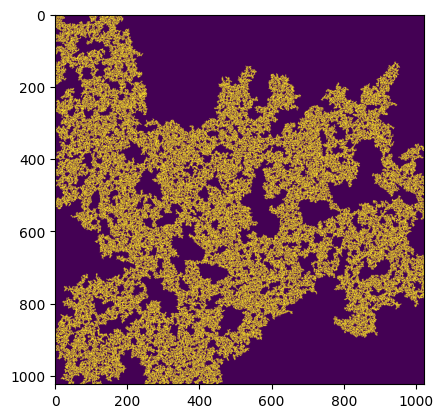

In [9]:
p_c = 0.59274
L = 1024

M_labeled, num = scipy.ndimage.label(generate_conf(p_c, L))
sizes = Counter(M_labeled[M_labeled > 0].flatten())

biggest_label = max(sizes, key=sizes.get)
biggest_cluster = (M_labeled == biggest_label)
m_cl = biggest_cluster.astype(int)

plt.imshow(m_cl)
plt.show()

In [10]:
def box_counting(matrix, k):
    L, M = matrix.shape
    assert L == M    # make sure the provided matrix is square

    b = 2**k
    cell_count = 0
    for i in range(0, L, b):
        for j in range(0, L, b):
            if np.any(matrix[i:i+b, j:j+b]):
                cell_count += 1

    return cell_count

bs = []
N_bs = []
for k in range(10):
    bs.append(2**k)
    N_b = box_counting(m_cl, k)
    N_bs.append(N_b)

Fractal dimension of m_cl is 1.8276


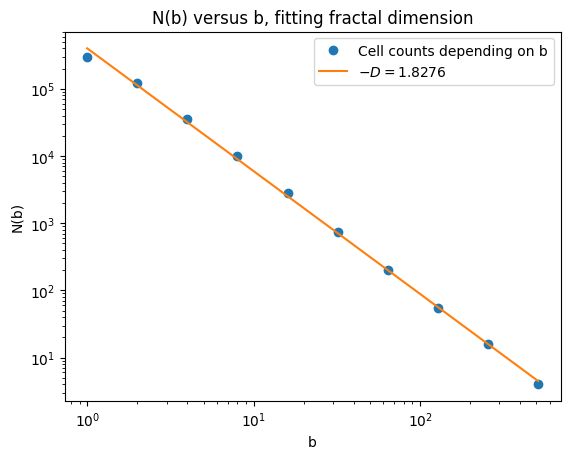

In [11]:
log_b = np.log(bs)
log_N = np.log(N_bs)

# Fit the line to find -D = slope
slope, intercept = np.polyfit(log_b, log_N, 1)

fractal_dimension = -slope
fit_values = np.exp(intercept) * (bs**slope)

print(f'Fractal dimension of m_cl is {fractal_dimension:.4f}')
fig, ax = plt.subplots()
ax.loglog(bs, N_bs, 'o', label='Cell counts depending on b')
ax.loglog(bs, fit_values, label=f'$-D = {-slope:.4f}$')

ax.set_title('N(b) versus b, fitting fractal dimension')
ax.set_xlabel('b')
ax.set_ylabel('N(b)')
ax.legend()
plt.show()

# 3.B Bond percolation 
In this part, we will use the networkx library to study bond percolation. 
You can find more about the library in:
https://networkx.org/documentation/stable/

In bond percolation, we the occupation probability is defined on the bond rather than on the sites. For a 2D square lattice the critical probability is known exactly as $p_c=1/2$.



In [12]:
import networkx as nx
import numpy as np

### Exercise 3.7. Create a bond percolation problem
Write a function to create a configuration of the bond percolation
problem on a square lattice of size nxn with occupation probability p

In [13]:
def create_bond_percolation_square(n,p):
    """" Function to create a configuration of the bond percolation
    problem on a square lattice of size nxn with occupation 
    probability p
    
    uses: networkx, numpy
    
    input: n, p
    
    output: the graph G and the positions pos 
    """
# hint: nx.grid_2d_graph and remove_edges_from from networkx
    graph = nx.grid_2d_graph(n, n)
    all_edges = list(graph.edges())
    p_del = 1 - p
    random_values = np.random.rand(len(all_edges)) # create a list of values in the range [0,  1.0)
    removed_edges = [all_edges[i] for i in range(len(all_edges)) if random_values[i] < p_del] # extract those edges that correspond to the value < p_del
    graph.remove_edges_from(removed_edges) # delete the extracted edges
    pos = {node: node for node in graph.nodes()}
    return graph, pos

In [14]:
# create a percolation graph
n=20
p=0.5
G, pos=create_bond_percolation_square(n,p)

Text(0.5, 1.0, 'Bond percolation lattice, occupation prob = 0.5')

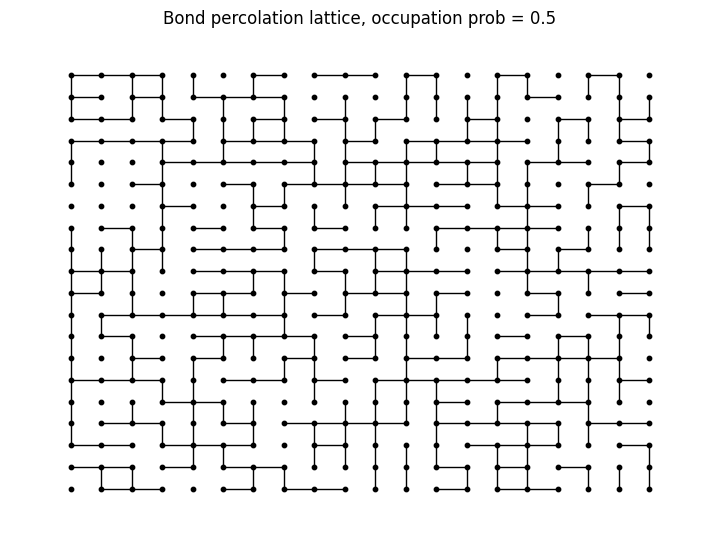

In [15]:
plt.figure(figsize=(7, 5))
nx.draw(G, pos, node_size=10, node_color='black')
plt.title(f'Bond percolation lattice, occupation prob = {p}')

Text(0.5, 1.0, 'Bond percolation lattice, occupation prob = 0.5')

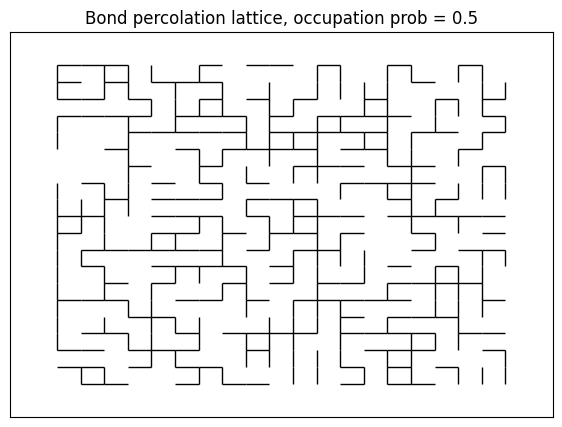

In [16]:
plt.figure(figsize=(7, 5))
nx.draw_networkx_edges(G, pos)
plt.title(f'Bond percolation lattice, occupation prob = {p}')

Now the lattice is stored in the graph object G and the position in pos


### Exercise 3.8. Clusters in bond percolation
Repeat Exercise 3.2 and 3.3 for the case of bond percolation. In particular:
- identify the clusters
- plot the configurations using random colors for each clusters and a selection of values of p
- compute the cluster distribution at $p=p_c=1/2$ for a large n


In [17]:
# Hint: to obtain the clusters you can split the graph in connected components 
components = sorted(nx.connected_components(G), key=len, reverse=True)
# S = [G.subgraph(c).copy() for c in components]
num_components = len(components)

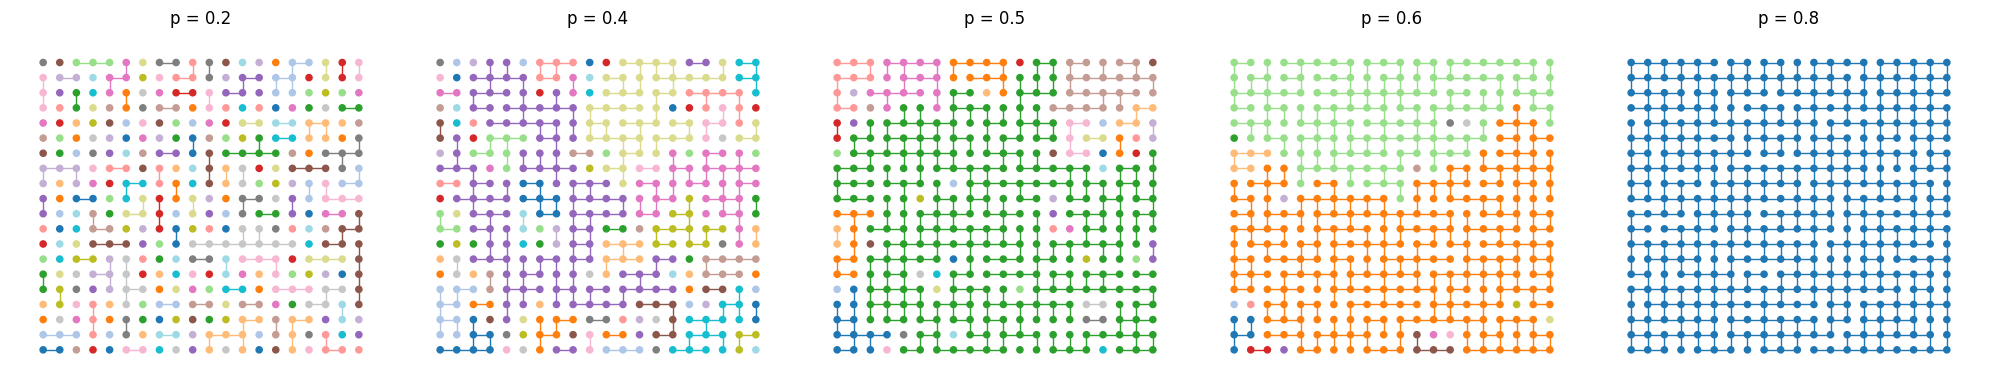

In [18]:
# For different values of p, generate a lattice, identify the clusters, plot them with unique colours
p_values = [0.2, 0.4, 0.5, 0.6, 0.8]
n = 20
rows, cols = 1, len(p_values)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4))
cmap1 = plt.get_cmap('tab20') 

for i, p in enumerate(p_values):
    G, pos = create_bond_percolation_square(n, p)
    # Identify clusters
    components = list(nx.connected_components(G))
    
    # Assign a color to every node based on which component it belongs to
    node_colors = {}
    for cluster_idx, nodes in enumerate(components):
        color = cmap1(cluster_idx % 20) # Loop through colors if > 20 clusters
        for node in nodes:
            node_colors[node] = color
            
    # Re-order colors to match G.nodes()
    color_list = [node_colors[node] for node in G.nodes()]
    edge_colors = [node_colors[u] for u, v in G.edges()]

    ax = axes[i]
    nx.draw(
        G, pos, ax=ax, 
        node_size=20, 
        node_color=color_list, 
        edge_color=edge_colors, 
        width=1,
        with_labels=False
    )
    ax.set_title(f"p = {p}")

plt.tight_layout()
plt.show()

Computing the distribution of clusters in a bond percolation lattice.

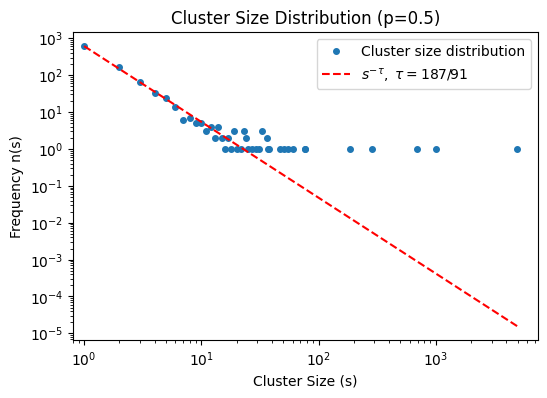

In [19]:
# Compute cluster distribution for p=0.5
n = 100
p_c = 0.5
G_c, pos_c = create_bond_percolation_square(n, p_c)

components = nx.connected_components(G_c)
component_list = list(components)
    
# Assign a color to every node based on which component it belongs to
node_colors = {}
for cluster_idx, nodes in enumerate(component_list):
    color = cmap1(cluster_idx % 20) # Loop through colors if > 20 clusters
    for node in nodes:
        node_colors[node] = color
        
# Re-order colors to match G.nodes()
color_list = [node_colors[node] for node in G_c.nodes()]
edge_colors = [node_colors[u] for u, v in G_c.edges()]

cluster_sizes = [len(c) for c in component_list]
size_distribution = Counter(cluster_sizes)

sizes = sorted(size_distribution.keys())
counts = [size_distribution[s] for s in sizes]

unique_sizes, size_counts = np.unique(sizes, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(sizes, counts, 'o', markersize=4, label='Cluster size distribution')
ax.set_title(f"Cluster Size Distribution (p={p_c})")
tau = 187/91
s_range = np.logspace(0, np.log10(unique_sizes.max()), 200)
C = size_distribution[1] 
y_theory = C * (s_range**-tau)

ax.loglog(s_range, y_theory, 'r--', label=r'$s^{-\tau},\ \tau=187/91$')
plt.xlim(0.8, max(cluster_sizes) * 1.5)
ax.set_xlabel("Cluster Size (s)")
ax.set_ylabel("Frequency n(s)")
plt.legend()
plt.show()

Here we can see that both for site and bond percolation cases, the cluster distribution at the critical value p follow the same power law, hence we see universality. The low tail does not follow the red line because of finite size effect (the lattice is too small).

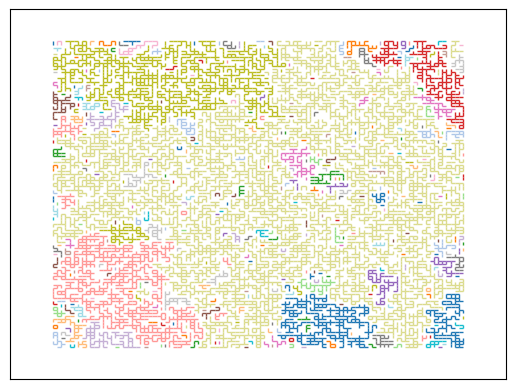

In [20]:
# The big lattice
nx.draw_networkx_edges(G_c, pos_c, edge_color=edge_colors)

### Exercise 3.9. Order parameter and finite size scaling for bond percolation
Repeat Exercise 3.4 and 3.5 for the case of bond percolation. Compare the results with the case of site percolation.
Create a plot with the finite size scaling, with both site and bond percolation curves in the same graph. Do they match?



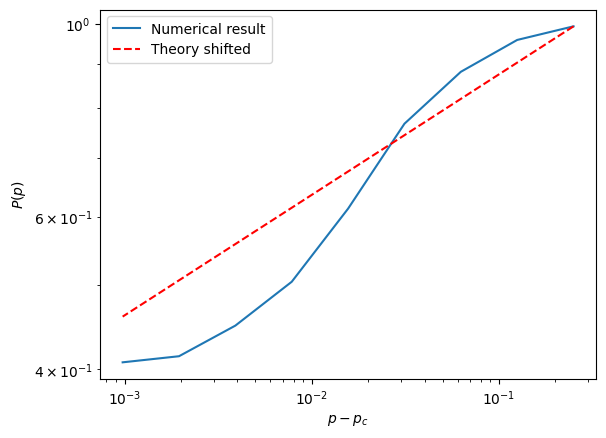

In [21]:
# Exercise 3.4 for bond percolation - order parameter scaling
N = 100
p_c = 0.5
beta = 5/36

cluster_frac = []
probabilities = []

for n in range(2, 11):
    p = p_c + 2**(-n)
    iters = []
    for _ in range(100):
        G, pos = create_bond_percolation_square(N, p)
        biggest_cluster_size = len(max(nx.connected_components(G), key=len))
        iters.append(biggest_cluster_size / N**2)

    mean_cluster_frac = np.mean(iters)
    cluster_frac.append(mean_cluster_frac)
    probabilities.append(p)

cluster_frac = np.array(cluster_frac)
probabilities = np.array(probabilities)
p_diff = probabilities - p_c

fig, ax = plt.subplots()
ax.loglog(p_diff, cluster_frac,  label='Numerical result')
shift = cluster_frac[0] / (p_diff[0]**beta)
ax.loglog(p_diff, shift * (p_diff**beta), 'r--', label='Theory shifted')

ax.set_xlabel('$p - p_c$')
ax.set_ylabel('$P(p)$')
ax.legend()
plt.show()

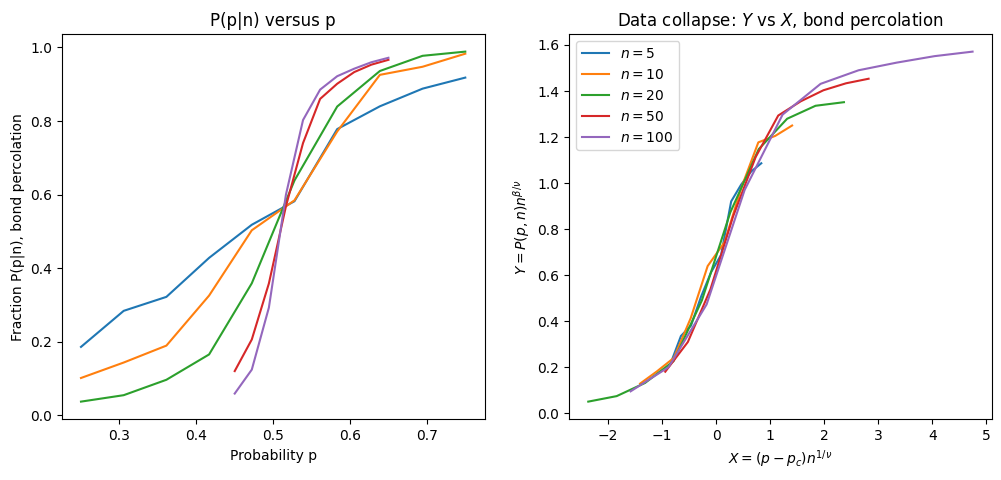

In [22]:
# Exercise 3.5 for bond percolation - finite size scaling
p_c = 0.5
beta = 5/36
nu = 4/3
Ns = [5, 10, 20, 50, 100]
probs_small = np.linspace(0.25, 0.75, 10)
probs_large = np.linspace(0.45, 0.65, 10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
for n in Ns:
    probs = probs_small if n in [5, 10, 20] else probs_large
    X = []
    Y = []
    probs_pn = []
    for p in probs:
        iters = []
        for _ in range(20):
            G, pos = create_bond_percolation_square(n, p)
            biggest_cluster_size = len(max(nx.connected_components(G), key=len))
            iters.append(biggest_cluster_size / n**2)
            
        prob_pn = np.mean(iters)
        probs_pn.append(prob_pn)

        X.append((p - p_c) * n**(1/nu))
        Y.append(prob_pn * n**(beta/nu))

    ax1.plot(probs, probs_pn, label=f'$n={n}$')
    ax2.plot(X, Y, label=f'$n={n}$')


ax1.set_title("P(p|n) versus p")
ax1.set_xlabel("Probability p")
ax1.set_ylabel("Fraction P(p|n), bond percolation")
ax2.set_title("Data collapse: $Y$ vs $X$, bond percolation")
ax2.set_xlabel(r"$X = (p-p_c) n^{1/\nu}$")
ax2.set_ylabel(r"$Y = P(p,n) n^{\beta/\nu}$")
ax2.legend()
plt.legend()
plt.show()

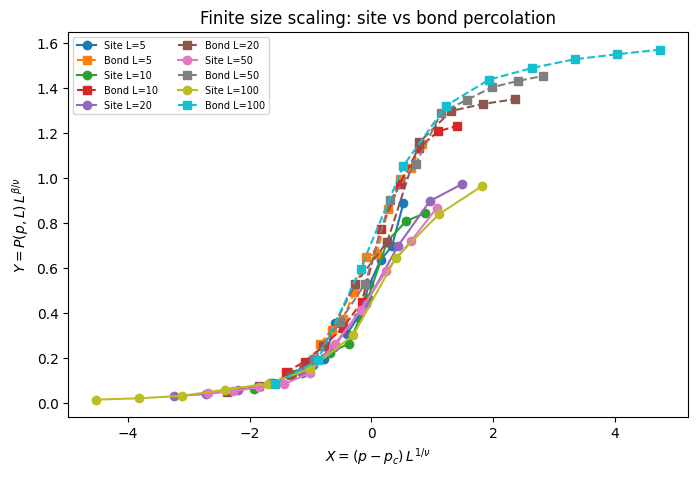

In [23]:
# Comparing directly finite size scaling for site and bond percolation
p_c_site = 0.59274
p_c_bond = 0.5
beta = 5/36
nu = 4/3
Ls = [5, 10, 20, 50, 100]

def compute_fss_data(percolation_type, L, p_c):
    """Returns (X, Y, probs_pL) arrays for one value of L."""
    probs = np.linspace(0.25, 0.75, 10) if L <= 20 else np.linspace(0.45, 0.65, 10)
    X, Y, probs_pL = [], [], []
    for p in probs:
        iters = []
        for _ in range(20):
            if percolation_type == 'site':
                M_labeled, _ = scipy.ndimage.label(generate_conf(p, L))
                biggest = get_cluster_sizes(M_labeled).max()
                iters.append(biggest / L**2)
            else:  # bond
                G, _ = create_bond_percolation_square(L, p)
                biggest = len(max(nx.connected_components(G), key=len))
                iters.append(biggest / L**2)
        prob_pL = np.mean(iters)
        probs_pL.append(prob_pL)
        X.append((p - p_c) * L**(1/nu))
        Y.append(prob_pL * L**(beta/nu))
    return X, Y, probs_pL

fig, ax = plt.subplots(figsize=(8, 5))

for L in Ls:
    X_site, Y_site, _ = compute_fss_data('site', L, p_c_site)
    X_bond, Y_bond, _ = compute_fss_data('bond', L, p_c_bond)
    ax.plot(X_site, Y_site, 'o-',  label=f'Site L={L}')
    ax.plot(X_bond, Y_bond, 's--', label=f'Bond L={L}')

ax.set_xlabel(r'$X = (p - p_c)\, L^{1/\nu}$')
ax.set_ylabel(r'$Y = P(p,L)\, L^{\beta/\nu}$')
ax.set_title('Finite size scaling: site vs bond percolation')
ax.legend(fontsize=7, ncol=2)
plt.show()

The data collapse shows that site and bond percolation curves (with their respective p_c values) fall onto the same universal scaling function when plotted as $Y = P(p,L) * L^{(β/ν)}$ vs $X = (p-p_c) * L^{(1/ν)}$. This confirms that both models belong to the same universality class, sharing exponents β=5/36 and ν=4/3. The deviations at large |X| for bigger L are expected finite-size effects, since the scaling form only holds close to p_c.

# 3.C Percolation for urban areas
Here we will apply percolation ideas to the quantification of urban boundaries, inspired by this work:

Oliveira, E.A., Furtado, V., Andrade, J.S. and Makse, H.A., 2018. A worldwide model for boundaries of urban settlements. Royal Society open science, 5(5), p.180468.
https://royalsocietypublishing.org/doi/full/10.1098/rsos.180468

Read the paper to have an idea.

Here you will do the following (corresponding to the simple city clustering algorithm): You are provided with a grid representing the population density D in Europe on a scale of 5km. You should take the grid and define a density threshold $D_0$. If $D>D_0$ the cell is considered to be part of a city, while for $D<D_0$ it is not.  The thresholded grid is now similar to a percolation problem (i.e. a matrix with elements 0 and 1).



### Excercise 3.10 Urban percolation
Study the properties of the grid as a function of $D_0$, assign cluster labels and then plot the map with a random color map (each cluster should be visualized with a different color). Find if there is a value of $D_0$ below which there is percolation (defined in some inventive way for this case). 



In [24]:
# Load population data (-1 is the sea!)
urban_matrix = np.loadtxt("matrix_city.txt")

<Axes: >

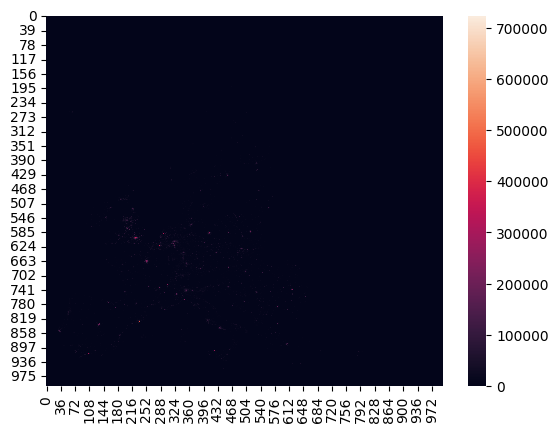

In [25]:
# Check areas with positive density to see the "map"
import seaborn as sns
import scipy.ndimage as nd

sns.heatmap(urban_matrix*(urban_matrix > 0))

Not very visible because the densiy values are in a big range.

<Axes: >

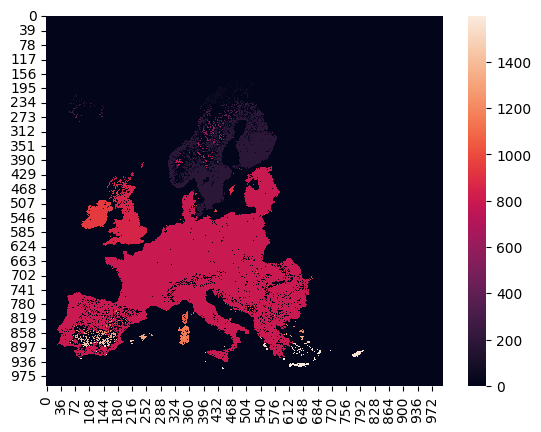

In [26]:
# Do initial clustering to see the map more clearly
labeled_land, num_land = scipy.ndimage.label(urban_matrix > 0)
sns.heatmap(labeled_land)

In [27]:
# Since there are islands, it would be impossible to have percolation to or from them, so we have to find mainland,
# which is all connected and discard the rest
sizes = np.bincount(labeled_land.ravel())
mainland_label = sizes[1:].argmax() + 1 # Skip background 0
mainland_mask = (labeled_land == mainland_label)

In [28]:
# Define percolation to be connection between the farthest bottom left corner (Portugal) farthest site in the top right corner of the mainland (Estonia)
# Get all land coordinates
y_coords, x_coords = np.where(mainland_mask)

# Portugal (roughly bottom-left of landmass)
# We can find the point with the minimum x + maximum y
portugal_idx = np.argmin(x_coords - y_coords) 
start_node = (y_coords[portugal_idx], x_coords[portugal_idx])

# Estonia (roughly top-right of landmass)
estonia_idx = np.argmax(x_coords - y_coords)
end_node = (y_coords[estonia_idx], x_coords[estonia_idx])

print(f"Path Start: {start_node}, Path End: {end_node}")

Path Start: (np.int64(889), np.int64(28)), Path End: (np.int64(407), np.int64(569))


In [29]:
# To check whether the two chosen sites for percolation are connected, check if they belong to the same cluster
def check_portugal_to_estonia(binary_grid, start, end):
    # Only create graph for the 'On' pixels
    labeled, num = scipy.ndimage.label(binary_grid)
    
    start_label = labeled[start]
    end_label = labeled[end]
    
    # If both are part of the same non-zero cluster, they are connected
    return (start_label != 0) and (start_label == end_label)

In [30]:
mainland = urban_matrix * mainland_mask
max_d = np.max(mainland)
print(f"Max density in the used data: {max_d}")

# 1. Setup thresholds (using log-space because population is skewed)
thresholds = np.geomspace(1, max_d, 50)[::-1]

# Pre-calculate land area
total_land_pixels = np.sum(mainland > 0)

results = []
path_open_at = None

for D0 in thresholds:
    mask = (mainland >= D0).astype(int)
    labeled, num_features = nd.label(mask)
    
    if num_features > 0:
        # Get sizes of all clusters
        sizes = np.bincount(labeled.ravel())
        max_size = sizes[1:].max() # Skip background
        p_max = max_size / total_land_pixels
        
        # Check Portugal to Estonia path
        connected = (labeled[start_node] != 0) and (labeled[start_node] == labeled[end_node])
        
        if connected and path_open_at is None:
            path_open_at = D0
            print(f"Path from Portugal to Estonia opens at D_0 = {D0}")
            
        results.append((D0, p_max, connected))

results = np.array(results)
d_vals = results[:, 0]
p_max_vals = results[:, 1]

Max density in the used data: 722991.0
Path from Portugal to Estonia opens at D_0 = 11.917008955519666


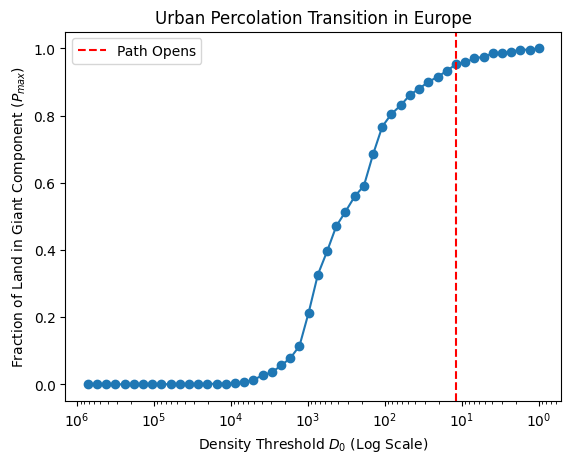

In [31]:
plt.semilogx(d_vals, p_max_vals, 'o-')
plt.axvline(path_open_at, color='r', linestyle='--', label='Path Opens')
plt.xlabel('Density Threshold $D_0$ (Log Scale)')
plt.ylabel('Fraction of Land in Giant Component ($P_{max}$)')
plt.title('Urban Percolation Transition in Europe')
plt.gca().invert_xaxis() #  Invert so moving right = lowering threshold (increasing p)
plt.legend()
plt.show()

<Axes: >

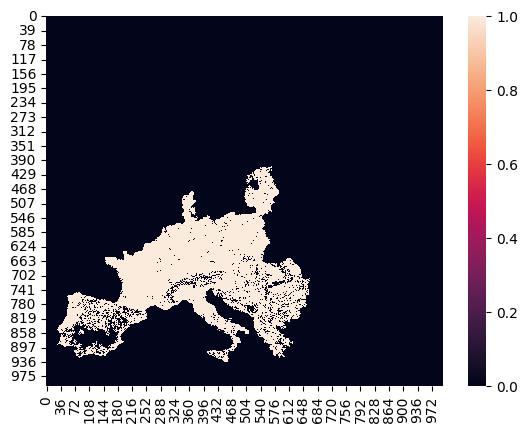

In [32]:
# Visualise the map when the two chosen sites are first connected
mask = (mainland >= path_open_at).astype(int)
sns.heatmap(mask)

Because the threshold value is so low $D_0$  $\approx$ 12 persons, so to connect my chosen sites - Estonia to Portugal - it makes the rest of the graph very thickly connected. That suggests that my chosen sites are small villages, which agrees with the geography.

### Excercise 3.11 Urban cluster distribution
Compute the cluster size distribution as a function of $D_0$.

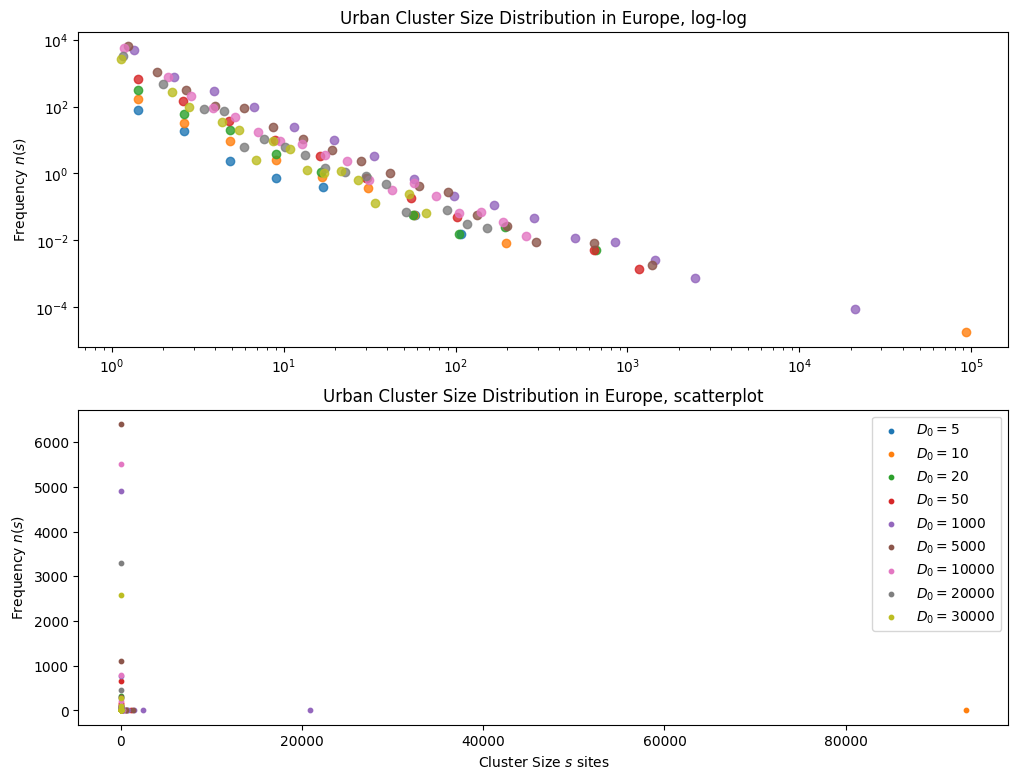

In [33]:
D0_list = [5, 10, 20, 50, 1000, 5000, 10000, 20000, 30000]
def plot_cluster_distribution(density_grid, D0_list):
    figure, axes = plt.subplots(2, 1, figsize=(12, 9))
    
    for D0 in D0_list:
        # Create mask and label
        mask = (density_grid >= D0) & (density_grid > 0)
        labeled, num = nd.label(mask)
        
        # Get sizes
        sizes = np.bincount(labeled.ravel())[1:]
        
        if len(sizes) == 0: continue
        
        # Calculate frequency n(s)
        unique_sizes, counts = np.unique(sizes, return_counts=True)
        
        bins = np.logspace(0, np.log10(unique_sizes.max()), 20)
        hist, bin_edges = np.histogram(sizes, bins=bins)

        # Calculate bin centers and normalize by bin width
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_widths = np.diff(bin_edges)
        normalized_hist = hist / bin_widths

        mask_pos = normalized_hist > 0
        # Plot only the non-zero data
        axes[0].loglog(bin_centers[mask_pos], normalized_hist[mask_pos], 'o', label=f'$D_0 = {D0}$', alpha=0.8)
        axes[1].scatter(bin_centers[mask_pos], normalized_hist[mask_pos], label=f'$D_0 = {D0}$', s=10)

    # axes[0].set_xlabel('Cluster Size $s$ sites')
    axes[0].set_ylabel('Frequency $n(s)$')
    axes[1].set_xlabel('Cluster Size $s$ sites')
    axes[1].set_ylabel('Frequency $n(s)$')
    axes[0].set_title('Urban Cluster Size Distribution in Europe, log-log')
    axes[1].set_title('Urban Cluster Size Distribution in Europe, scatterplot')
    plt.legend()
    plt.show()

plot_cluster_distribution(mainland, D0_list)

The data shows that a significant continental component exists even at $D_0 \approx 1000$, which represents the dense 'urban skeleton' of Europe (cities and suburbs). The 'gap' between this state and the final saturation at $D_0 \approx 10$ suggests that while the major urban centers are connected at high densities, the final geographic extremities of the mainland only join the cluster through low-density rural areas or small villages ($D_0 \approx 10-20$).